# Exploratory Data Analysis

In [102]:
source("src/functions_and_things.r")

load_libraries()

In [103]:
s_grey = "#7C858C"
s_blue = "#008EB7"

In [104]:
df <- read.csv("data/processed/combined_data_weekly.csv")

df |>
  filter(week > "2024-06-06" & 
         week < "2025-05-31") -> df

head(df)

,week,coords_cbd,ridership,min_temp,rain,snow
,<chr>,<lgl>,<int>,<dbl>,<dbl>,<dbl>
1,2024-06-09,FALSE,12123413,63.42857,3.40,0
2,2024-06-09,TRUE,4968744,63.42857,1.70,0
3,2024-06-16,FALSE,11674738,67.28571,0.16,0
4,2024-06-16,TRUE,4803242,67.28571,0.08,0
5,2024-06-23,FALSE,11931641,67.85714,3.40,0
6,2024-06-23,TRUE,4922153,67.85714,1.70,0


## Plots

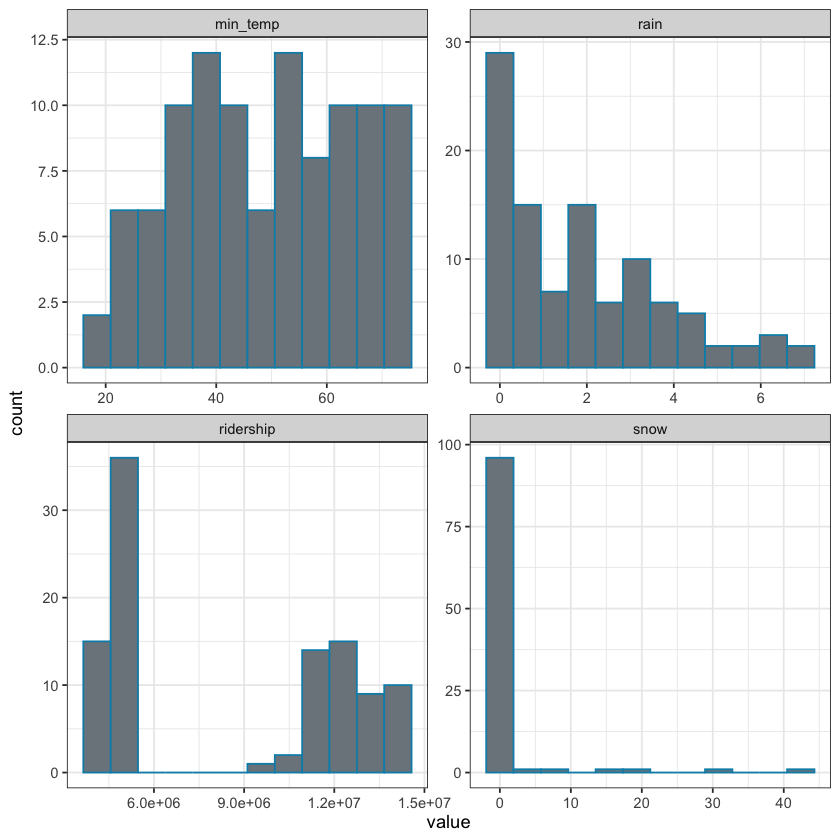

In [105]:
# ref. classwork 2 

df |> 
    keep(is.numeric) |> 
    gather() |>
    ggplot(aes(x = value)) + 
    facet_wrap(~ key, scales = "free") +
    geom_histogram(bins = 12, color = s_blue, fill = s_grey) +
    theme_bw()

## Beginning time series 

In [106]:
df$week = as.Date(df$week)

class(df$week)

[1] "Date"

In [107]:
nrow(df)

[1] 102

In [108]:
sum(is.na(df$ridership))

[1] 0

In [109]:
n_distinct(df$week)

[1] 51

In [110]:
df |> 
    arrange(week) |> 
    mutate(ridership_ma = rollmean(ridership, 14, fill = NA, align = "center")) -> df 

Warning message:
“Removed 13 rows containing missing values or values outside the scale range
(`geom_line()`).”


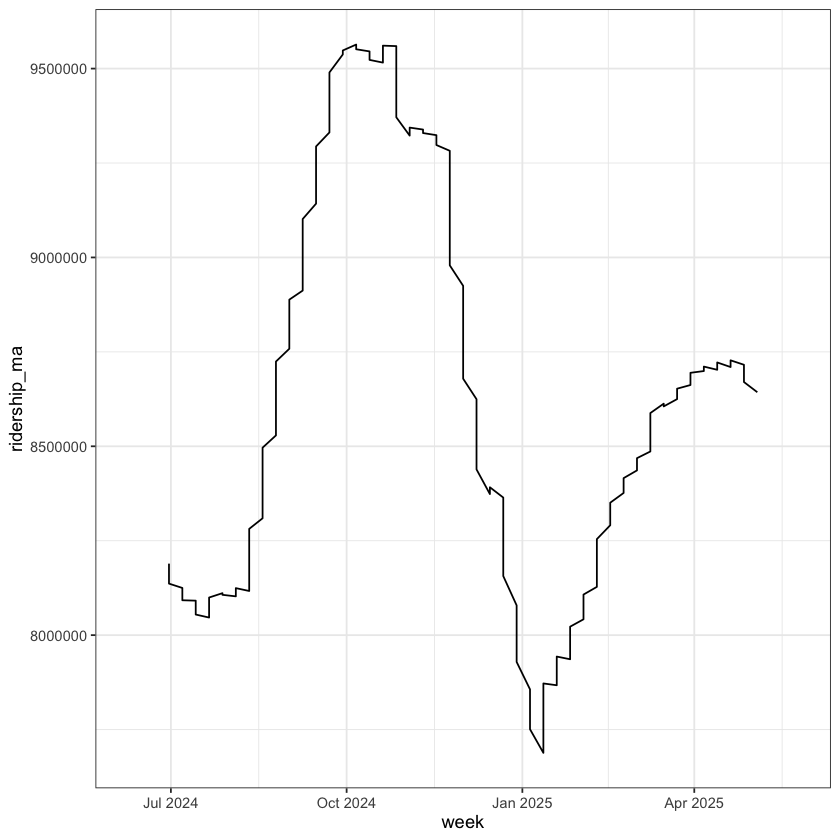

In [111]:
ggplot(df, aes(x = week)) + 
    geom_line(aes(y = ridership_ma)) + 
    theme_bw()

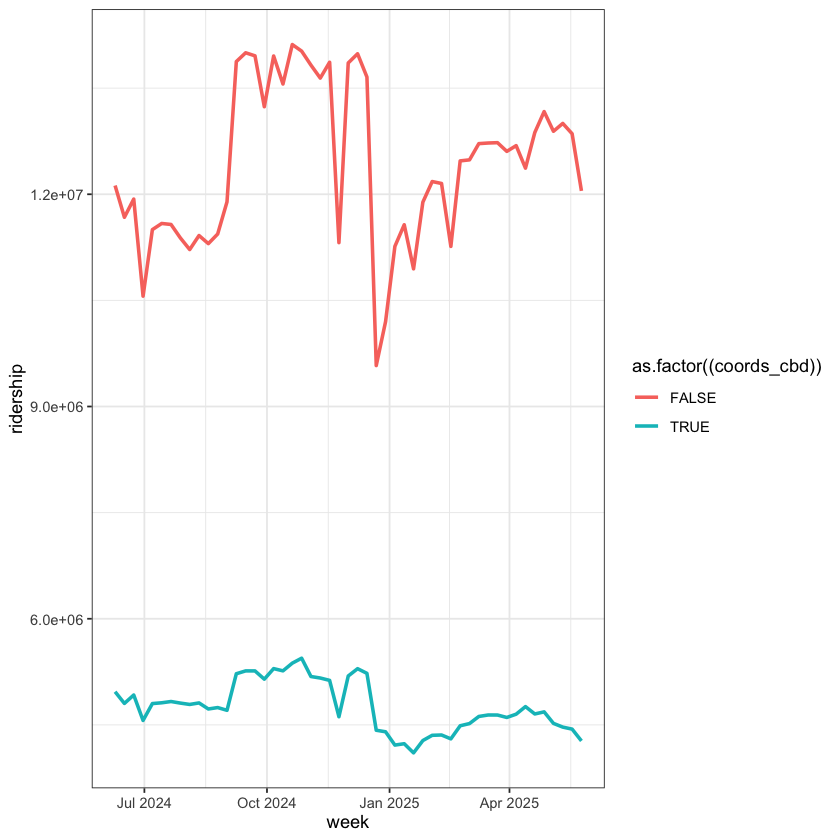

In [112]:
ggplot(df, aes(x = week, y = ridership, color = as.factor((coords_cbd)))) + 
    geom_line(lwd = 1) + theme_bw()

In [1]:
ggplot(df, aes(x = week, y = ridership, color = as.factor((borough)))) + 
    geom_line()

ERROR: Error in ggplot(df, aes(x = week, y = ridership, color = as.factor((borough)))): could not find function "ggplot"


## Corelations 